# PINNs for Inverse problem
@Bahae-Eddine Madir

In [1]:
import sys
sys.path.insert(1, '../Utilities/')

In [2]:
import torch
import numpy as np
from tqdm.notebook import tqdm

In [3]:
from sampling import *
from AutoDiff import AG_grad

In [4]:
import matplotlib.pyplot as plt
from matplotlib import rc
#rc('text', usetex=True)
rc('xtick', direction='in', top=True)
rc('ytick', direction='in', right=True)

In [5]:
import scienceplots
plt.style.use(['science', 'ieee'])

In [6]:
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif':'Times New Roman'})
rc('legend', **{'frameon': True, 'fancybox': False, 'edgecolor': "k", 'framealpha':1, 'fontsize': 8, 'handlelength':1.25})

In [7]:
import matplotlib.ticker as ticker
def fmt(x, pos):
    a, b = '{:.1e}'.format(x).split('e')
    b = int(b)
    return r'${}$e${}$'.format(a, b)

In [8]:
save = True
savefile = "./outputs/inverse/"

In [9]:
torch.manual_seed(1234)
class ff(torch.nn.Module):
    def __init__(self, n_neurones):
        super().__init__()

        self.l1 = torch.nn.Linear(2, n_neurones)
        self.act = torch.nn.Tanh()
        self.l2 = torch.nn.Linear(n_neurones, 1)

        self.params_dict = dict(self.named_parameters())
        
    def forward(self, *inputs):
        inputs = torch.cat(inputs, 1)
        outputs = self.act(self.l1(inputs))
        return self.l2(outputs)

In [10]:
device = torch.device("cpu")

In [11]:
net1 = ff(15).to(device)
net2 = ff(15).to(device)

In [12]:
model_u = lambda x, y: x*(1-x)* y* (1-y)* net1(x, y)
model_D = net2

In [13]:
u_ref = lambda x, y: torch.sin(torch.pi* x)* torch.sin(np.pi* y)
D_ref = lambda x, y: 0.5* x* (torch.sin(2* torch.pi* y))
f = lambda x, y: - (torch.pi/2)* torch.sin(2* torch.pi* y)* torch.cos(torch.pi* x)* torch.sin(torch.pi* y) \
    - (torch.pi**2* x)* torch.cos(2* torch.pi* y)* torch.sin(torch.pi* x)* torch.cos(torch.pi* y) \
    + 2* torch.pi**2 * D_ref(x, y)* u_ref(x, y)

In [14]:
x = torch.linspace(0, 1, 50)
x, y = torch.meshgrid(x, x, indexing='xy')

## Losses

In [15]:
def res_mse(x, y, f):

    if not x.requires_grad:
        x.requires_grad_()
    if not y.requires_grad:
        y.requires_grad_()
    
    u = model_u(x, y)
    D = model_D(x, y)
    u_x, u_y = AG_grad(u, (x, y))
    u_xx, u_yy = AG_grad(u, (x, y), order=2)
    D_x, D_y = AG_grad(D, (x, y))

    res = (D_x* u_x + D_y* u_y + D* (u_xx + u_yy)).flatten() + f(x, y).flatten()
    return (res**2).mean()

## Data

In [16]:
n_res = 51**2
#n_bdry = 4* 51

In [17]:
xl, xu = 0., 1.
yl, yu = 0., 1.
zeros = lambda *args: np.zeros_like(args[0])

In [18]:
res_sampler =  Sampler([xl, yl], [xu, yu], zeros)
x_res, y_res, _ = res_sampler.sample(n_res, device=device)

In [19]:
u_ref_np = lambda x, y: np.sin(np.pi* x)* np.sin(np.pi* y)
D_ref_np = lambda x, y: 0.5* x* (np.sin(2* torch.pi* y))

In [20]:
n_u = 20
# n_D = 4

In [21]:
u_sampler = Sampler([xl, yl], [xu, yu], u_ref_np)
x_u, y_u, out_u = u_sampler.sample(n_u, device=device)

In [22]:
def mse(x, y=0):
    return ((x - y)**2).mean()

## Optimization

In [23]:
w_d = 1000

In [24]:
losses = {'data':[], 'physics':[], 'total':[], 'l2_u':[], 'l2_D':[]}

def closure():
    global l_phys, l_data
    net1.zero_grad()
    net2.zero_grad()
    
    l_phys = res_mse(x_res, y_res, f)
    l_data = mse(model_u(x_u, y_u), out_u) # + mse(model_D(x_D, y_D), out_D)
    
    loss = l_phys + w_d* l_data
    loss.backward()
    
    return loss

In [25]:
n_epochs = 201

In [26]:
optim1 = torch.optim.LBFGS(
    net1.parameters(), 
    line_search_fn="strong_wolfe"
)

optim2 = torch.optim.LBFGS(
    net2.parameters(), 
    line_search_fn="strong_wolfe"
)

In [27]:
def err_l2(ref, pred):
    return np.linalg.norm(ref - pred, 2) / np.linalg.norm(ref, 2)

In [28]:
x = torch.linspace(0, 1, 100)
x, y = torch.meshgrid(x, x, indexing='xy')

#pred_u = model_u(x.reshape(-1, 1), y.reshape(-1, 1)).detach().reshape(100, 100)
ref_u = u_ref(x, y)

#pred_D = model_D(x.reshape(-1, 1), y.reshape(-1, 1)).detach().reshape(100, 100)
ref_D = D_ref(x, y)

In [29]:
%%time

for _ in tqdm(range(n_epochs)) :
    
    loss = optim1.step(closure)
    loss = optim2.step(closure)
    
    losses['data'].append(l_data.item())
    losses['physics'].append(l_phys.item())
    losses['total'].append(loss.item())

    pred_u = model_u(x.reshape(-1, 1), y.reshape(-1, 1)).detach().reshape(100, 100)
    losses['l2_u'].append(err_l2(ref_u, pred_u))

    pred_D = model_D(x.reshape(-1, 1), y.reshape(-1, 1)).detach().reshape(100, 100)
    losses['l2_D'].append(err_l2(ref_D, pred_D))

  0%|          | 0/201 [00:00<?, ?it/s]

CPU times: user 5min 53s, sys: 1.8 s, total: 5min 55s
Wall time: 46.4 s


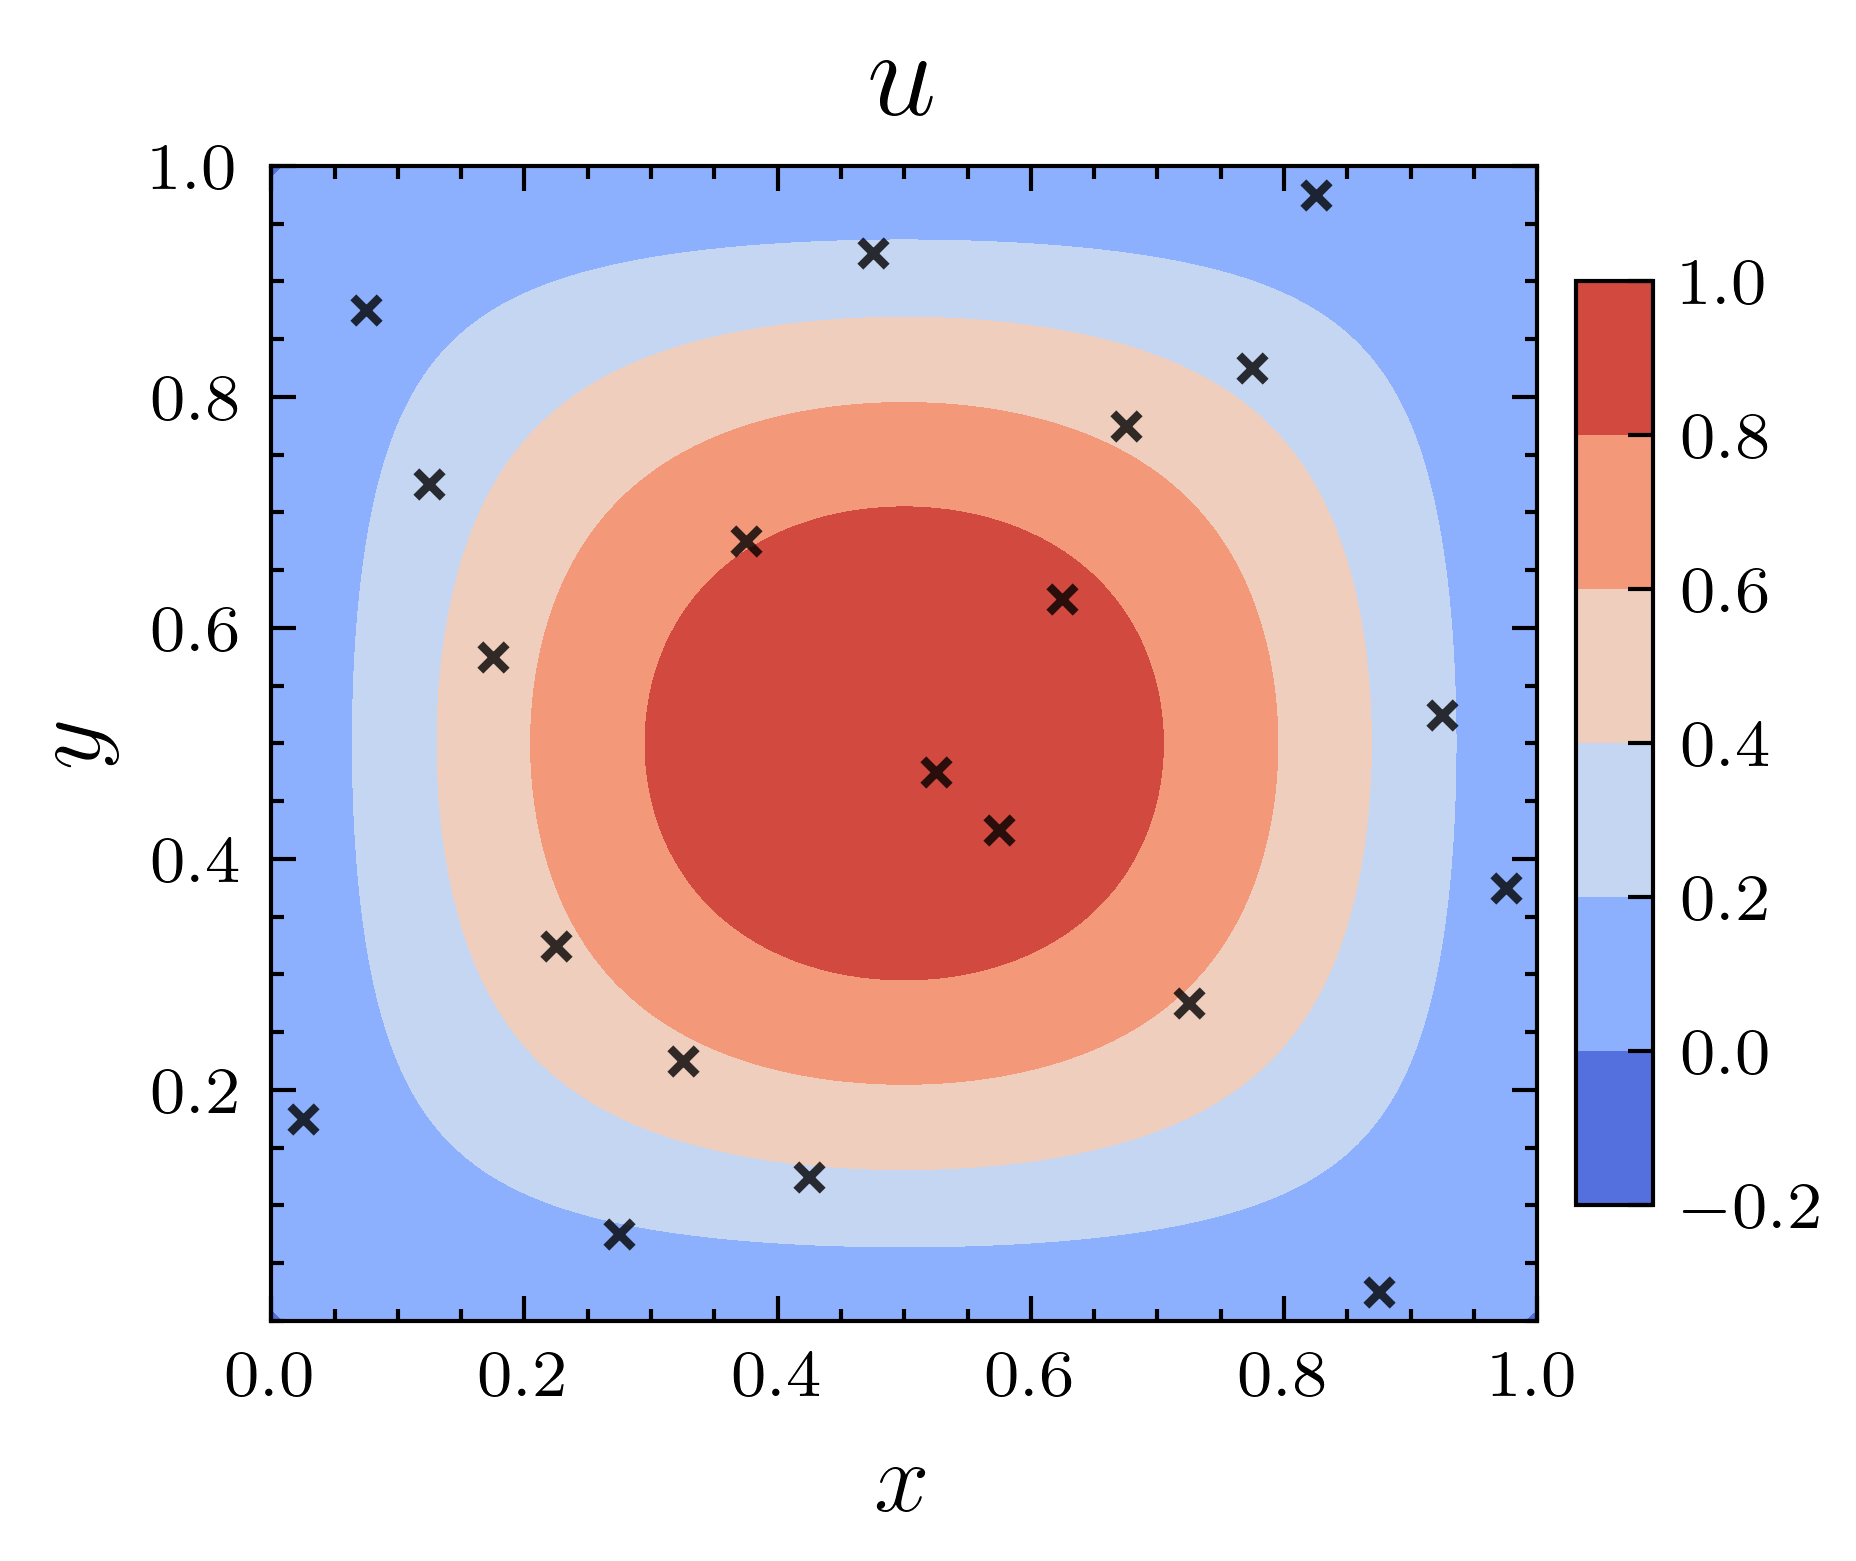

In [30]:
fig, axs = plt.subplots(1, 1)
#plt.subplots_adjust(wspace=.5)
axs = [axs]
#cb = axs[0].contourf(x, y, pred_u, cmap='coolwarm', levels=10)
ctf = axs[0].contourf(x, y, ref_u, cmap='coolwarm', levels=4)
fig.colorbar(ctf, shrink=.8, aspect=12, ax=axs[0], pad=.025)
axs[0].scatter(x_u, y_u, lw=1, s=10, alpha=.8, c='k', marker='x')


#axs[0].scatter(x_u, y_u, s=5, alpha=.8, c='k', marker='x')
#axs[1].scatter(x_D, y_D, s=2, alpha=.5, c='k', marker='x')

#axs[0].set_title(r'$\widehat{u}$ ', pad=10, fontsize=12)
#axs[1].set_title(r'$\widehat{D}$ ', pad=10, fontsize=12)

axs[0].set_title(r'$u$ ', fontsize=15)
axs[0].set_ylabel("$y$", fontsize=12)
axs[0].set_xlabel("$x$", fontsize=12)

axs[0].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0].set_yticks([0.2, 0.4, 0.6, 0.8, 1])

#plt.legend(loc='upper right')

if save:
    #plt.savefig(savefile + 'pred.pdf', bbox_inches ='tight')
    plt.savefig(savefile + 'ref.pdf', bbox_inches ='tight')
    
plt.show()

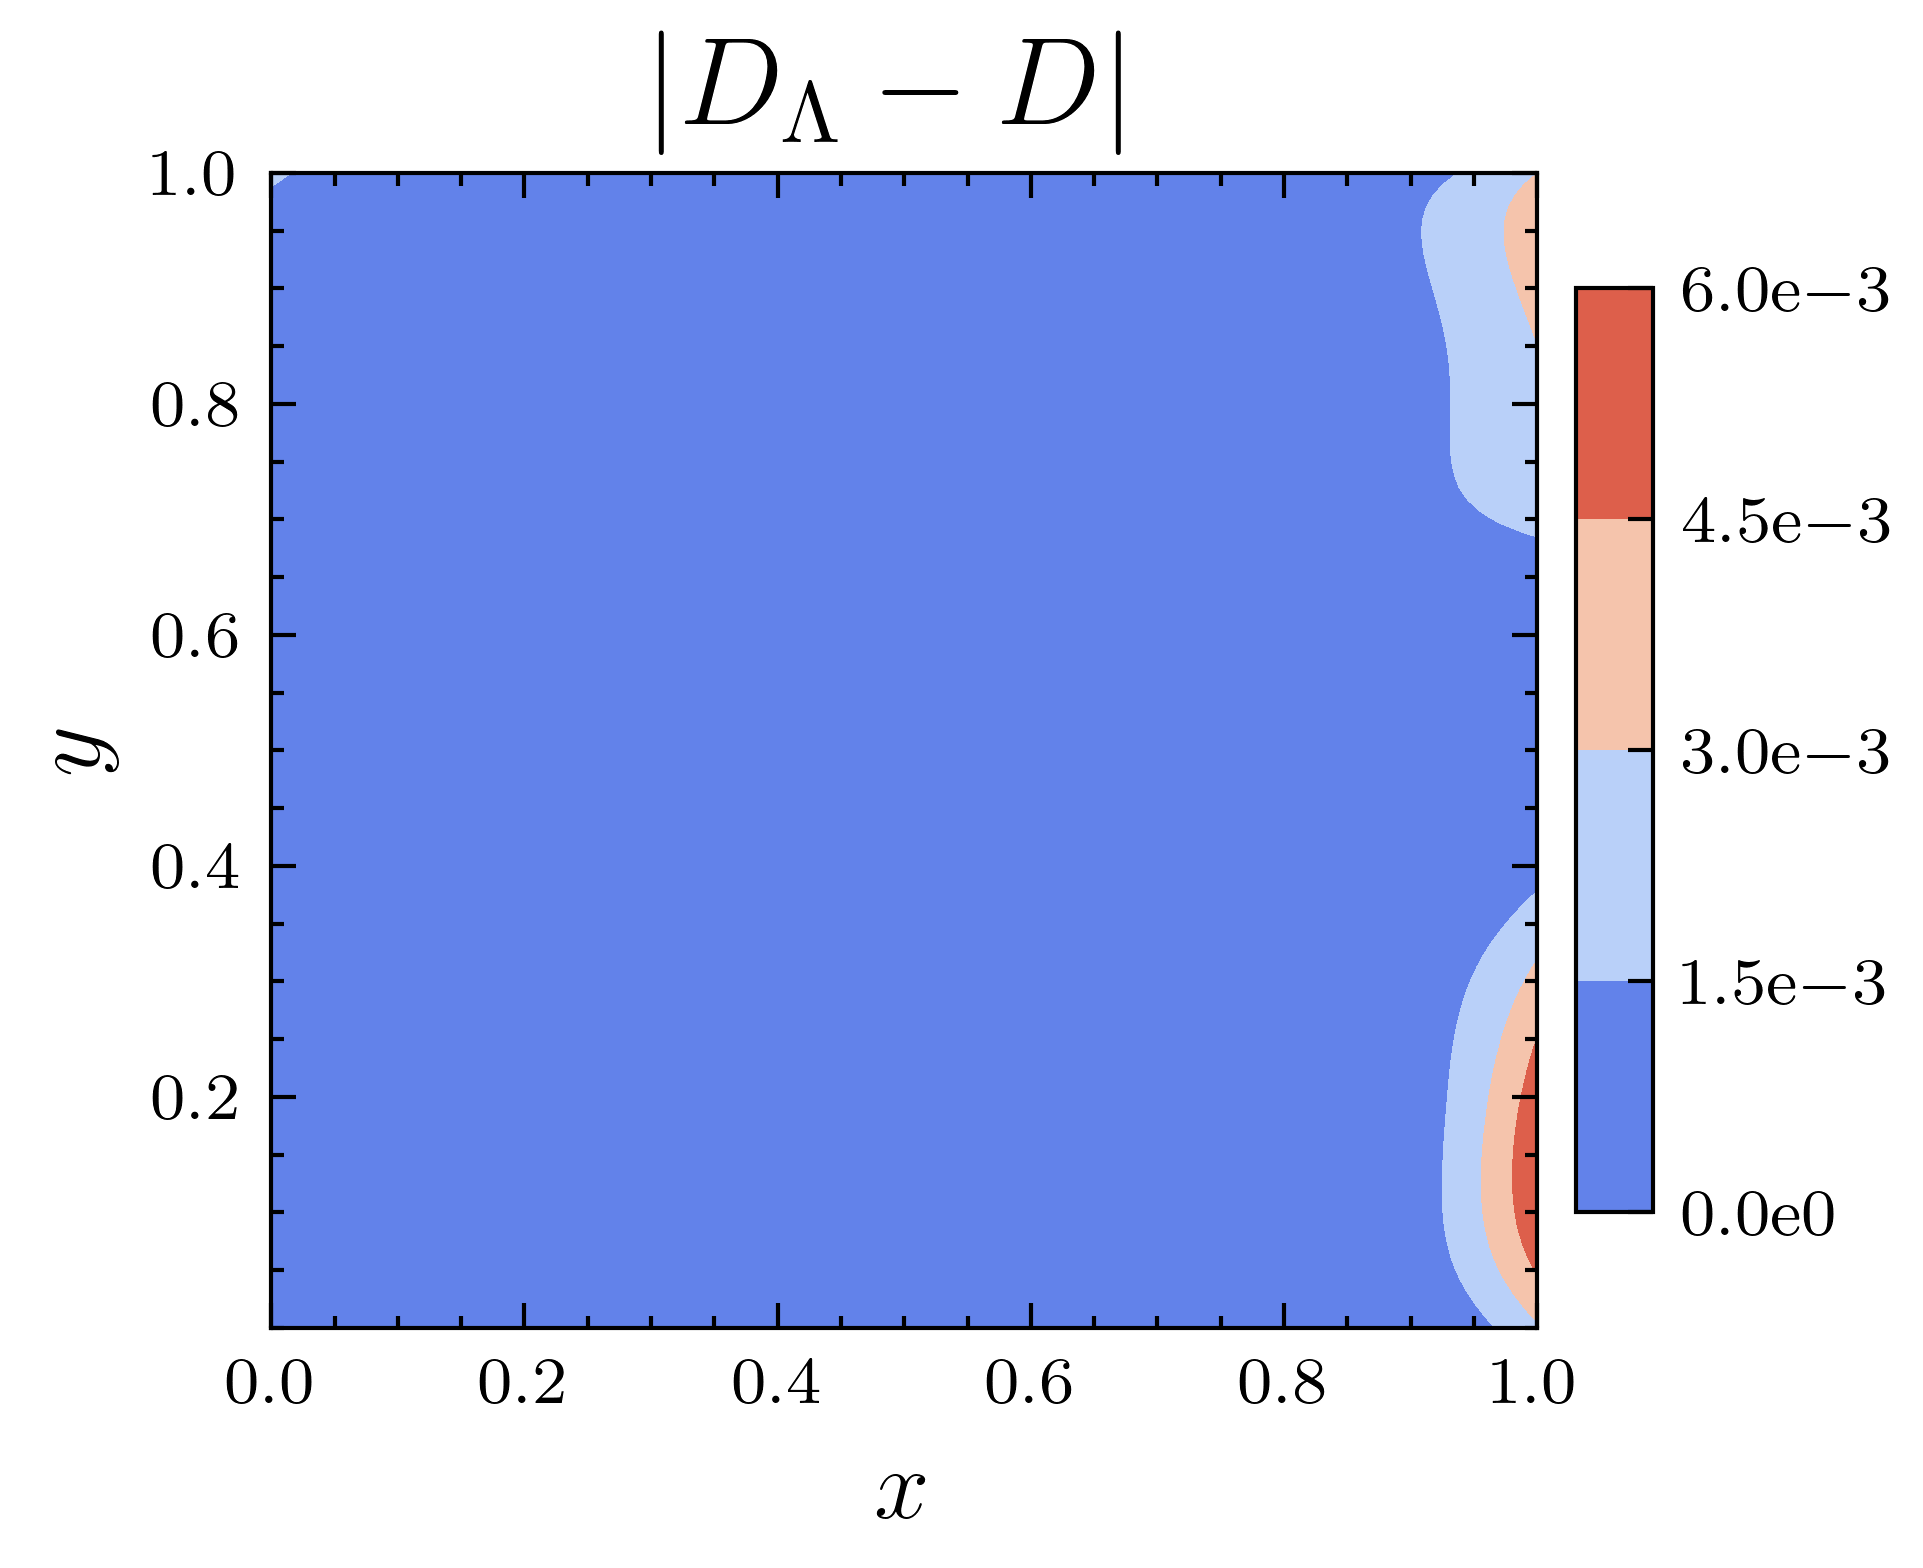

In [60]:
fig, axs = plt.subplots(1, 1)

axs = [axs]

ctf = axs[0].contourf(x, y, (pred_D - ref_D).abs(), cmap='coolwarm', levels=4)
fig.colorbar(ctf, ax=axs[0], shrink=.8, aspect=12, pad=.025, format=ticker.FuncFormatter(fmt))

axs[0].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axs[0].set_yticks([0.2, 0.4, 0.6, 0.8, 1])

axs[0].set_title(r'$ |D_{\Lambda} - D| $ ', fontsize=15)

axs[0].set_ylabel("$y$", fontsize=12)
axs[0].set_xlabel("$x$", fontsize=12)

if save:
    plt.savefig(savefile + 'abs_error.pdf', bbox_inches ='tight')
    
plt.show()

In [36]:
print(f'Rel. L2 error u: {err_l2(ref_u, pred_u) :.3e}')
print(f'Rel. L2 error D: {err_l2(ref_D, pred_D) :.3e}')

Rel. L2 error u: 4.288e-04
Rel. L2 error D: 3.483e-03


In [37]:
epochs = range(n_epochs)

In [52]:
marker_kw = dict(
    markevery=15, markersize=5, markerfacecolor="none")

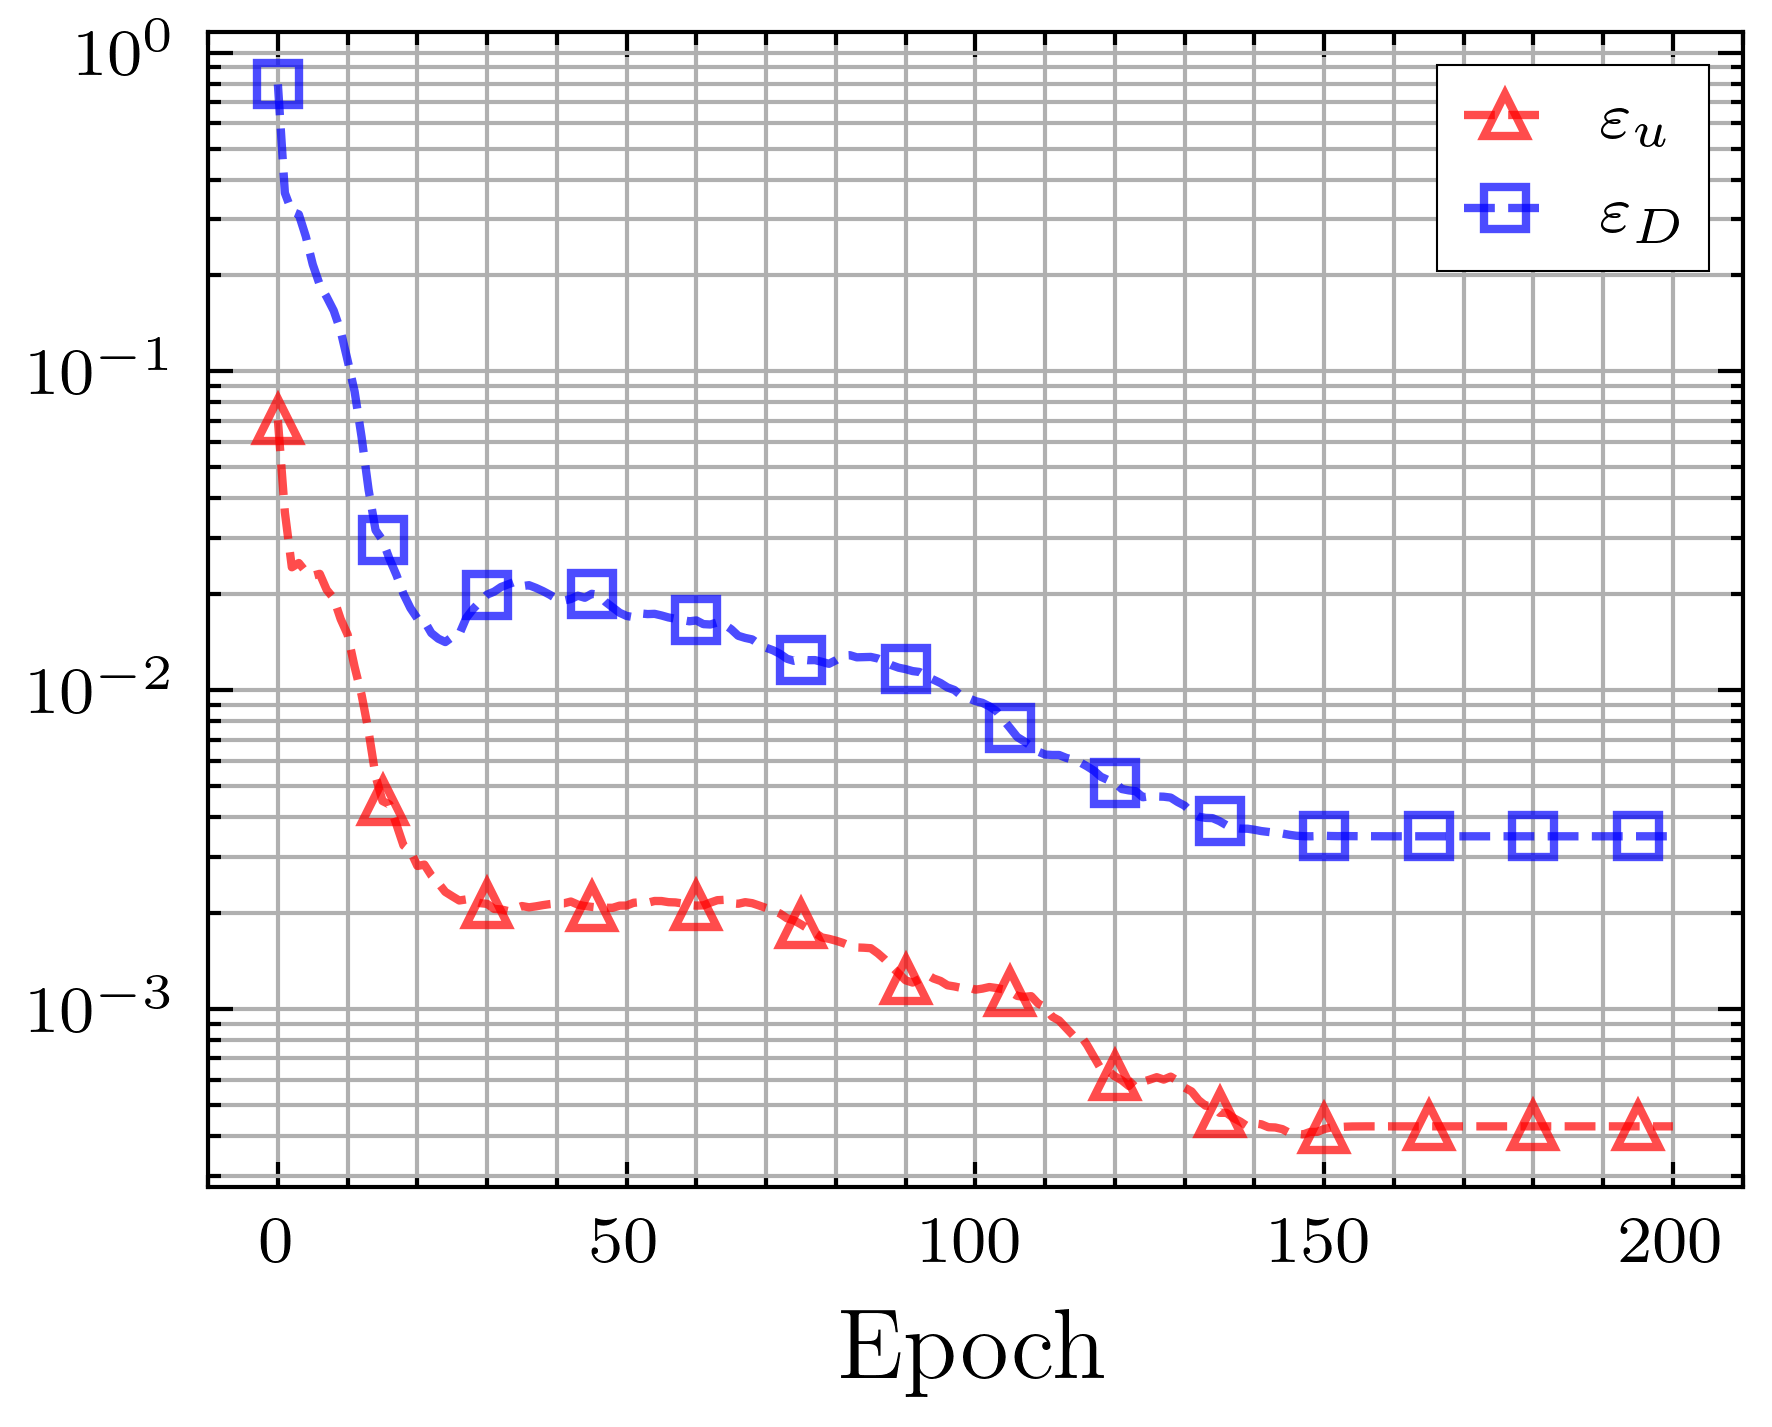

In [59]:
fig, axs = plt.subplots(1, 1)

axs.grid(True, 'both')
axs.set_yscale('log')
axs.set_xlabel('Epoch', fontsize=12)

axs.plot(epochs, losses['l2_u'], "^--", c='r', alpha=.7, label=r'$\varepsilon_u$', **marker_kw)
axs.plot(epochs, losses['l2_D'], "s--", c='b', alpha=.7, label=r'$\varepsilon_D$', **marker_kw)

#axs.set_xticks(epochs[::25])
axs.legend().get_frame().set_linewidth(0.25)

if save:
    plt.savefig(savefile + 'losses.pdf', bbox_inches ='tight')
    
plt.show()